# 1. Introducción y descripción del problema

## Dataset

Para esta actividad se utilizará el dataset **Breast Cancer Wisconsin (Diagnostic)**, disponible en **Scikit-learn** mediante `sklearn.datasets.load_breast_cancer`.

Este conjunto de datos contiene información obtenida a partir de imágenes digitalizadas de muestras de tejido mamario. Las características describen diferentes propiedades de los núcleos celulares presentes en las muestras.

## Problema a analizar

El objetivo del análisis es construir un modelo de **clasificación** capaz de determinar si un tumor es **maligno o benigno** a partir de las características obtenidas de la muestra.

Este problema pertenece al aprendizaje supervisado, ya que cada observación del dataset cuenta con una clase conocida que puede utilizarse para entrenar y evaluar los modelos.

## Variable objetivo

La variable objetivo es `target`, la cual representa el diagnóstico del tumor:

- **0:** Maligno
- **1:** Benigno

Por lo tanto, se trata de un problema de **clasificación binaria**.

## ¿Qué representa cada observación?

Cada fila del dataset representa una muestra correspondiente a un tumor analizado.

Cada observación contiene diferentes mediciones relacionadas con características de los núcleos celulares, como el radio, textura, perímetro, área, suavidad, concavidad y simetría, entre otras.

Estas características serán utilizadas como variables predictoras para determinar la clase del tumor.

## Métrica principal de evaluación

La métrica principal utilizada será el **recall de la clase maligna**.

El recall mide qué proporción de los casos malignos reales fueron correctamente identificados por el modelo.

\[Recall = \frac{TP}{TP + FN}\]

donde:

- **TP (True Positives):** casos malignos identificados correctamente.
- **FN (False Negatives):** casos malignos que el modelo clasificó incorrectamente como benignos.

## Justificación de la métrica

Se seleccionó el **recall** como métrica principal debido a que, en este problema, es especialmente importante reducir la cantidad de tumores malignos que son clasificados erróneamente como benignos.

Un falso negativo podría representar un caso en el que una muestra maligna no sea detectada por el modelo. Por esta razón, interesa que el modelo sea capaz de identificar la mayor proporción posible de los casos malignos.

Como métrica complementaria se utilizará el **F1-score**, ya que permite evaluar el equilibrio entre **precision** y **recall**, proporcionando una visión adicional del desempeño del modelo.

# 2. Carga y separación de los datos

En esta sección se cargará el dataset **Breast Cancer Wisconsin (Diagnostic)** y se realizará una revisión inicial de los datos.

Se analizarán lo tipos de variables, valores faltantes, registros duplicados y la distribución de la variable objetivo. Posteriormente, se separarán las variables predictoras de la variable objetivo y se dividirán los datos en conjuntos de entrenamiento y prueba.

Para garantizar que los resultados puedan reproducirse, se utilizará una semilla fija de 42. Además, debido a que se trata de un problema de clasificación, se utilizará estratificación para conservar aproximadamente la misma proporción de casos benignos y malignos en los conjuntos de entrenamiento y prueba.

## 2.1 Importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

## 2.2 Carga del dataset

In [ ]:
cancer = load_breast_cancer()

df = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

df["target"] = cancer.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2.3 Dimensiones del dataset

In [ ]:
print("Número de filas: ", df.shape[0])
print("Número de columnas: ", df.shape[1])

Número de filas:  569
Número de columnas:  31


El número de las filas representa la cantidad de observaciones disponibles, mientras que las columnas corresponden a las variables predictorias más la variable objetivo `target`

## 2.4 Revisión de los tipos de datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

También se pueden consultar directamente los tipos de datos:

In [ ]:
df.dtypes

,0
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


Las variables predictorias son principalmente variables numéricas continuas, por lo que es necesario realizar codificación de variables categóricas

## 2.5 Revisión de valores faltantes

In [ ]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


## 2.6 Revisión de registros duplicados

In [ ]:
duplicados = df.duplicated().sum()

print("Registros duplicados: ", duplicados)

Registros duplicados:  0


## 2.7 Distribución de la variable objetivo

In [ ]:
df["target"].value_counts()

,count
target,
1,357
0,212


Para mostrar las clases utilizando sus nombres:

In [ ]:
distribucion = df["target"].value_counts().rename(
    index={
        0: "Maligno",
        1: "Benigno"
    }
)

distribucion

,count
target,
Benigno,357
Maligno,212


También se puede observar la distribución porcentual:

In [ ]:
porcentajes = df["target"].value_counts(normalize=True) * 100

porcentajes.rename(
    index={
        0: "Maligno",
        1: "Benigno"
    }
)

porcentajes

,proportion
target,
1,62.741652
0,37.258348


## 2.8 Visualización de la distribución de clases

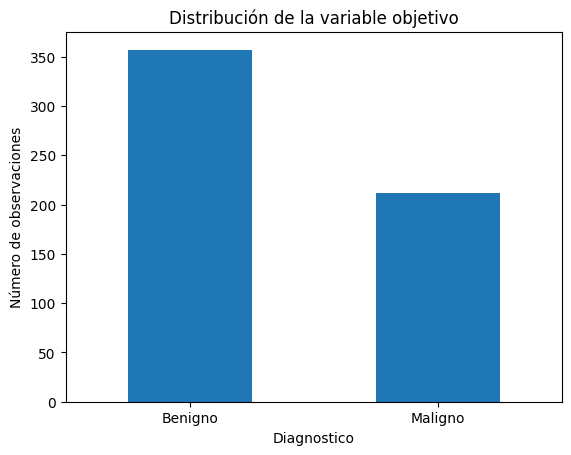

In [ ]:
distribucion.plot(kind="bar")

plt.title("Distribución de la variable objetivo")
plt.xlabel("Diagnostico")
plt.ylabel("Número de observaciones")
plt.xticks(rotation=0)
plt.show()

Esta revisión permite identificar si existe un desbalance entre las clases. Aunque la cantidad de casos benignos es mayor que la de casos malignos, ambas clases cuentan con una cantidad considerable de observaciones.

## 2.9 Separación de variables predictorias y variable objetivo

In [ ]:
X = df.drop(columns="target")
y = df["target"]

print("Dimensiones de X: ", X.shape)
print("Dimensiones de y: ", y.shape)

Dimensiones de X:  (569, 30)
Dimensiones de y:  (569,)


## 2.10 División de entrenamiento y prueba

Se utilizará una división de ** 80% para entrenamiento y 20% para prueba**.

La opción `stratify=y` permite conservar aproximadamente la misma proporción de tumores benignos y malignos en ambos conjuntos.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## 2.11 Verificación de la estratificación

In [ ]:
print("Distribución en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True))

Distribución en entrenamiento:
target
1    0.626374
0    0.373626
Name: proportion, dtype: float64

Distribución en prueba:
target
1    0.631579
0    0.368421
Name: proportion, dtype: float64


Las proporciones de ambas clases deben ser similares en los conjuntos de entrenamiento y prueba, lo que permite realizar una evaluación más consistente del modelo.

## 2.12 Consideraciones sobre el escalamiento

Las características del dataset representan diferentes esacalas. Sin embargo, el modelo base que se utilizará posteriormente será un algoritmo basado en árboles, como **Random Forest**

Los modelos basados en árboles no dependen directamente de las distancias entre observaciones y realizan divisiones utilizando umbrales sobre cada característica de manera independiente. Por esta razón **Random Forest no requiere escalamiento de las variables para funcionar correctamente**.

En caso de utilizar posteriormente una técnica de selección o transformación que sí dependa de la escala de las características, el escalamiento se incorporará dentro de un Pipeline para evitar la fuga de información.

# 3. Modelo base con RandomForest

En esta sección se construirá un modelo base utilizando **Random Forest**, un algoritmo de ensamble que combina múltiples árboles de decisión para generar una predicción final más robusta.

Se utilizará una configuración inicial razonable sin realizar todavía optimización de hiperparámetros. El propósito de este modelo es establecer una referencia que posteriormente pueda compararse con el modelo reducido y con el modelo optimizado.

La métrica principal será el **recall de la clase maligna**, mientras que como métrica complementaria se utilizará el **F1-score**.

## 3.1 Importación de librerías

In [ ]:
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, f1_score, accuracy_score

## 3.2 Creación del modelo base

Se utilizará un modelo RandomForestClassifier con 100 árboles y una semilla fija de 42 para garantizar que los resultados puedan reproducirse.

In [ ]:
modelo_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

En esta primera versión no se realizará optimización de hiperparámetros, ya que el objetivo es obtener un punto de referencia inicial.

## 3.3 Entrenamiento del modelo

También se registrará el tiempo aproximado que tarda el modelo en entrenarse.

In [ ]:
inicio = time.time()

modelo_base.fit(X_train, y_train)

fin = time.time()

tiempo_base = fin - inicio

print(f"Tiempo de entrenamiento: {tiempo_base:.4f} segundos")

Tiempo de entrenamiento: 0.2843 segundos


## 3.4 Predicciones sobre el conjunto de prueba.

Una vez entrenado el modelo, se realizarán predicciones utilizando los datos de prueba.

In [ ]:
y_pred_base = modelo_base.predict(X_test)

## 3.5 Evaluación del modelo base

Debido a que en este dataset la clase:



*   0 representa un tumor **maligno**
*   1 representa un tumor **benigno**

se utilizará pos_label = 0 para calcular específicamente el recall y F1-score de los casos malignos.



In [ ]:
recall_base = recall_score(
    y_test,
    y_pred_base,
    pos_label=0
)

f1_base = f1_score(
    y_test,
    y_pred_base,
    pos_label=0
)

accuracy_base = accuracy_score(
    y_test,
    y_pred_base
)

print(f" Recall clase maligna: {recall_base:.4f}")
print(f"F1-score clase maligna: {f1_base:.4f}")
print(f"Accuracy: {accuracy_base:.4f}")

 Recall clase maligna: 0.9286
F1-score clase maligna: 0.9398
Accuracy: 0.9561


Aunque la métrica principal de esta actividad será el **recall**, también se calcula el accuracy como información adicional sobre el comportamiento general del modelo.

## 3.6 Número de características utilizadas.

In [ ]:
num_caracteristicas_base = X_train.shape[1]

print("Número de características utilizadas: ", num_caracteristicas_base)

Número de características utilizadas:  30


El modelo base utiliza todas las características diponibles en el dataset.

## 3.7 Resumen modelo base

In [ ]:
resultados_base = pd.DataFrame({
    "Modelo": ["Random Forest base"],
    "Número de características": [num_caracteristicas_base],
    "Recall": [recall_base],
    "F1-score": [f1_base],
    "Accuracy": [accuracy_base],
    "Tiempo de entrenamiento": [tiempo_base]
})

resultados_base

,Modelo,Número de características,Recall,F1-score,Accuracy,Tiempo de entrenamiento
0,Random Forest base,30,0.928571,0.939759,0.95614,0.284302


## Interpretación inicial

El modelo base permite establecer un punto de referencia para las siguientes etapas de la actividad.

El **recall de la clase maligna** indica qué proporción de los tumores malignos reales fueron correctamente identificados. Un valor alto de recall es importante en este problema debido a que se busca reducir la cantidad de casos malignos clasificados incorrectamente como benignos.

El **F1-score** complementa esta evaluación al considerar simultáneamente el recall y la precisión del modelo.

Posteriormente, estos resultados serán comparados con un modelo que utilice un conjunto reducido de características y con un modelo optimizado mediante búsqueda de hiperparámetros.

# 4. Selección de características

Después de construir el modelo base, se analizarán las variables disponibles con el objetivo de reducir información poco relevante o redundante.

Para esta actividad se utilizará **SelectFromModel**, una técnica de selección de características que utiliza la importancia calculada por el modelo para determinar qué variables conservar.

Se utilizará un **Random Forest** como estimador interno debido a que este algoritmo permite calcular la importancia relativa de cada característica durante el entrenamiento.

La selección se ajustará utilizado únicamente los datos de entrenamiento para evitar **fuga de información (data leakage)**.

## 4.1 Importación de SelectFromModel

In [ ]:
from sklearn.feature_selection import SelectFromModel

## 4.2 Creación del selector

Se utilizará un Random Forest con la misma semilla utilizada anteriormente.

El criterio de selección será threshold="median", lo que significa que se conservarán las características cuya importancia sea igual o superior a la mediana de las importancias obtenidas por el modelo.

In [ ]:
selector = SelectFromModel(
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    threshold="median"
)

## 4.3 Ajuste utilizando únicamente los datos de entrenamiento

El selector se ajusta exclusivamente con `X_train` y `y_train`.

In [ ]:
selector.fit(X_train, y_train)

SelectFromModel(estimator=RandomForestClassifier(random_state=42),
                threshold='median')

Es importante no utilizar el conjunto de prueba durante este proceso, ya que este debe permanecer separado hasta la evaluación del modelo.

Si se utilizaran los datos de prueba para seleccionar las características, se estaría introduciendo información externa al proceso de entrenamiento y los resultados podrían ser demasiado optimistas.

## 4.4 Transformación de los conjuntos de entrenamiento y prueba

Una vez ajustado el selector, se aplica la misma transformación tanto al conjunto de entrenamiento como al conjunto de prueba.

In [ ]:
X_train_reducido = selector.transform(X_train)
X_test_reducido = selector.transform(X_test)

print("Dimensiones originales:", X_train.shape)
print("Dimensiones después de la selección:", X_train_reducido.shape)

Dimensiones originales: (455, 30)
Dimensiones después de la selección: (455, 15)


De esta manera se reduce el número de variables utilizadas por el modelo sin modificar las observaciones existentes.

## 4.5 Número de características seleccionadas

In [ ]:
num_caracteristicas_reducidas = selector.get_support().sum()

print("Características originales", X_train.shape[1])
print("Características seleccionadas:", num_caracteristicas_reducidas)

Características originales 30
Características seleccionadas: 15


El número conserva únicamente aquellas características que cumplen con el criterio de importancia establecido.

## 4.6 Identificación de las características seleccionadas

`get_support()` permite obtener una máscara que indica cuáles variables fueron conservadas.

In [ ]:
caracteristicas_seleccionadas = X_train.columns[
    selector.get_support()
]

print("Características seleccionadas: ")

for caracteristica in caracteristicas_seleccionadas:
  print(" - ", caracteristica)

Características seleccionadas: 
 -  mean radius
 -  mean perimeter
 -  mean area
 -  mean concavity
 -  mean concave points
 -  radius error
 -  area error
 -  worst radius
 -  worst texture
 -  worst perimeter
 -  worst area
 -  worst smoothness
 -  worst compactness
 -  worst concavity
 -  worst concave points


También pueden visualizarse en forma de lista:

In [ ]:
list(caracteristicas_seleccionadas)

['mean radius',
 'mean perimeter',
 'mean area',
 'mean concavity',
 'mean concave points',
 'radius error',
 'area error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points']

## 4.7 Importancia de las variables

El modelo utilizado internamente por `SelectFromModel` permite obtener la importancia asignada a cada variable.

In [ ]:
importancias = selector.estimator_.feature_importances_

tabla_importancias = pd.DataFrame({
    "Característica": X_train.columns,
    "Importancia": importancias,
    "Seleccionada": selector.get_support()
})

tabla_importancias = tabla_importancias.sort_values(
    by="Importancia",
    ascending=False
)

tabla_importancias

,Característica,Importancia,Seleccionada
23,worst area,0.140016,True
27,worst concave points,0.129530,True
20,worst radius,0.097696,True
7,mean concave points,0.090885,True
22,worst perimeter,0.072226,True
2,mean perimeter,0.069574,True
0,mean radius,0.068676,True
6,mean concavity,0.057638,True
3,mean area,0.049172,True
26,worst concavity,0.034340,True


Esta tabla permite observar qué características fueron consideradas más importantes para distinguir entre tumores malignos y benignos.

## 4.8 Visualización de las características más importantes.

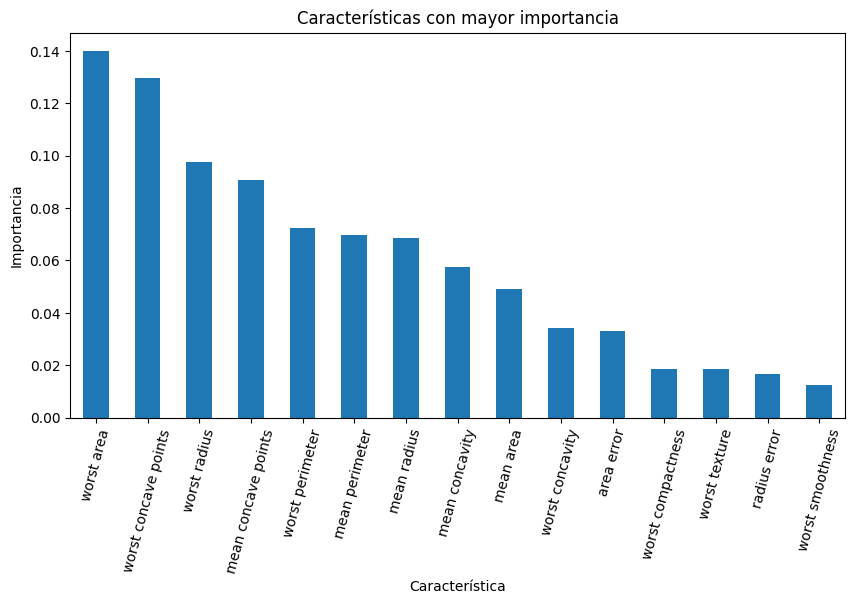

In [ ]:
tabla_importancias.head(15).plot(
    x="Característica",
    y="Importancia",
    kind="bar",
    legend=False,
    figsize=(10, 5)
)

plt.title("Características con mayor importancia")
plt.xlabel("Característica")
plt.ylabel("Importancia")
plt.xticks(rotation=75)

plt.show()

## Criterio utilizado para la selección

SelectFromModel utiliza la importancia de las características calculada por el modelo seleccionado.

En este caso, **Random Forest** evalúa qué tan útiles son las variables para realizar las divisiones de los árboles que permiten distinguir entre las diferentes clases.

Las variables con mayor contribución reciben una importancia más alta.

Se utilizó la **mediana de las importancias** como umbral. Por lo tanto, las características con una importancia igual o superior a este valor son conservadas, mientras que las características con menor importancia son eliminadas.

## Efecto de la seleccion sobre los datos

La seleccion de características reduce la cantidad de variables utilizadas para representar cada observación, pero conserva las características originales seleccionadas.

A diferencia de técnicas como **PCA**, las variables no se combinan ni se transforman en nuevos componentes. Esto permite mantener la interpretación original de las características seleccionadas.

La reducción puede disminuir la complejidad del modelo y eliminar variables con poca contribución a las predicciones. Sin embargo, una reducción excesiva también podría eliminar información útil y disminuir el rendimiento.

En la siguiente sección se entrenará nuevamente el modelo utilizando únicamente estas características para determinar si es posible conservar o mejorar el desempeño del modelo base utilizando una representación más pequeña de los datos.

# 5. Modelo con características reducidas

En esta sección se entrenará nuevamente un modelo **Random Forest**, pero utilizando únicamente las características seleccionadas en la sección anterior.

Para que la comparación sea consistente, se mantendrá la misma configuración inicial utilizada en el modelo base, así como la misma semilla aleatoria.

## 5.1 Creación del modelo reducido

In [ ]:
modelo_reducido = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42
)

## 5.2 Entrenamiento del modelo reducido

Se medirá nuevamente el tiempo de entrenamiento

In [ ]:
inicio = time.time()

modelo_reducido.fit(
    X_train_reducido,
    y_train
)

fin = time.time()

tiempo_reducido = fin - inicio

print(f"Tiempo de entrenamiento: {tiempo_reducido:.4f} segundos")

Tiempo de entrenamiento: 0.3758 segundos


## 5.3 Predicciones

In [ ]:
y_pred_reducido = modelo_reducido.predict(
    X_test_reducido
)

## 5.4 Evaluación del modelo reducido

Se utilizarán las mismas métricas empleadas en el modelo base para garantizar una comparación justa.

La métrica principal continuará siendo el **recall de la clase maligna**

In [ ]:
recall_reducido = recall_score(
    y_test,
    y_pred_reducido,
    pos_label=0
)

f1_reducido = f1_score(
    y_test,
    y_pred_reducido,
    pos_label=0
)

accuracy_reducido = accuracy_score(
    y_test,
    y_pred_reducido
)

print(f"Recall clase maligna: {recall_reducido:.4f}")
print(f"F1-score clase maligna: {f1_reducido:.4f}")
print(f"Accuracy: {accuracy_reducido:.4f}")

Recall clase maligna: 0.9286
F1-score clase maligna: 0.9398
Accuracy: 0.9561


## 5.5 Comparación entre el modelo base y el modelo reducido

Para comparar los resultados de forma clara, se construirá una tabla con el número de características, la métrica principal, la métrica complementaria y el tiempo de entrenamiento de ambos modelos.

In [ ]:
comparacion_base_reducido = pd.DataFrame({
    "Configuración": [
        "Modelo base",
        "Modelo con selección"
    ],
    "Número de características": [
        num_caracteristicas_base,
        num_caracteristicas_reducidas
    ],
    "Recall": [
        recall_base,
        recall_reducido
    ],
    "F1-score": [
        f1_base,
        f1_reducido
    ],
    "Tiempo de entrenamiento": [
        tiempo_base,
        tiempo_reducido
    ]
})

comparacion_base_reducido

,Configuración,Número de características,Recall,F1-score,Tiempo de entrenamiento
0,Modelo base,30,0.928571,0.939759,0.284302
1,Modelo con selección,15,0.928571,0.939759,0.375814


## 5.6 Diferencias entre ambos modelos

También se pueden calcular las diferencias entre las métricas para observar con mayor claridad el efecto de la selección de características.

In [ ]:
print(
    "Cambio en Recall:",
    round(recall_reducido - recall_base, 4)
)

print(
    "Cambio en F1-score:",
    round(f1_reducido - f1_base, 4)
)

print(
    "Características eliminadas:",
    num_caracteristicas_base - num_caracteristicas_reducidas
)

Cambio en Recall: 0.0
Cambio en F1-score: 0.0
Características eliminadas: 15


## Interpretación

La comparación permite determinar si reducir el número de características afectó significativamente el desempeño del modelo.

Si el modelo reducido mantiene valores de recall y F1-score similares al modelo base, se puede considerar que la selección fue beneficiosa, ya que se logró representar el problema utilizando menos variables sin perder una cantidad importante de información.

Si además el tiempo de entrenamiento disminuye, la reducción también puede generar una mejora en eficiencia computacional.

Por otro lado, si el recall disminuye considerablemente, significaría que algunas de las características eliminadas contenían información relevante para identificar correctamente los tumores malignos.

Por esta razón, la selección de características no debe evaluarse únicamente por la cantidad de variables eliminadas, sino también por el efecto que produce sobre la capacidad predictiva del modelo.

# 6. Optimización de hiperparámetros

Una vez evaluado el modelo base y el modelo con selección de características, se realizará una búsqueda sistemática de hiperparámetros para encontrar una configuración de **Random Forest** con mejor desempeño.

Para esta etapa se utilizará **GridSearchCV**, que permite probar distintas combinaciones de hiperparámetros y evaluarlas mediante validación cruzada.

La búsqueda se realizará utilizando únicamente el conjunto de entrenamiento, mientras que el conjunto de prueba se reservará para la evaluación final.

## 6.1 Importación de **GridSearchCV**


In [ ]:
import time
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score, make_scorer

# 6.2 Métrica utilizada durante la búsqueda

Debido a que la métrica principal de esta actividad es el **recall de la clase maligna**, se creará una función de evaluación que considere la clase 0 como la clase de interés.

In [ ]:
recall_maligno = make_scorer(
    recall_score,
    pos_label=0
)

De esta manera, GridSearchCV seleccionará la combinación de hiperparámetros que logre identificar correctamente la mayor proporción posible de tumores malignos.

# 6.3 Definición del modelo

In [ ]:
rf_grid = RandomForestClassifier(
    random_state=42
)

# 6.4 Espacio de búsqueda

Se explorarán cuatro hiperparámetros relevantes de Random Forest:

*   n_estimators: número de árboles del bosque.
*   max_depth: profundidad máxima de cada árbol
*   min_samples_split: número mínimo de observaciones necesarias para dividir un nodo.
*   max_features: cantidad de características consideradas en cada división.



In [ ]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", "log2"]
}

Este espacio de búsqueda es suficientemente pequeño para mantener un tiempo de ejecución razonable pero permite comparar distintas configuraciones del modelo.

El número total de combinaciones es:


In [ ]:
total_combinaciones = (
    len(param_grid["n_estimators"])
    * len(param_grid["max_depth"])
    * len(param_grid["min_samples_split"])
    * len(param_grid["max_features"])
)

print("Número de combinaciones: ", total_combinaciones)

Número de combinaciones:  24


## 6.5 Configuración de GridSearchCV

Se utilizará validación cruzada con **5 particiones**

In [ ]:
grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    scoring=recall_maligno,
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

El parámetro cv=5 indica que los datos de entrenamiento se dividen en cinco partes. En cada iteración, cuatro partes se utilizan para entrenar el modelo y una para validarlo.

Este proceso se repite hasta que cada partición haya sido utilizada como conjunto de validación.

## 6.6 Ejecución de la búsqueda

Para mantener consistencia con la etapa de selección de características, la optimización se realizará utilizando el conjunto reducido.

In [ ]:
inicio_grid = time.time()

grid_search.fit(
    X_train_reducido,
    y_train
)

fin_grid = time.time()

tiempo_grid = fin_grid - inicio_grid

print(
    f"Tiempo de búsqueda: {tiempo_grid:.4f} segundos"
)

Tiempo de búsqueda: 41.2712 segundos


# 6.7 Mejor configuración encontrada

In [ ]:
print("Mejores hiperparámetros: ")
print(grid_search.best_params_)

print(
    "\nMejor Recall promedio en validación cruzada:",
    round(grid_search.best_score_, 4)
)

Mejores hiperparámetros: 
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}

Mejor Recall promedio en validación cruzada: 0.9529


best_params_ contiene la combinación que obtuvo el mejor recall promedio durante la validación cruzada.

# 6.8 Tabla de hiperparámetros

In [ ]:
mejores = grid_search.best_params_
tabla_hiperparametros = pd.DataFrame({
    "Hiperparámetro": [
        "n_estimators",
        "max_depth",
        "min_samples_split",
        "max_features"
    ],
    "Valores explorados": [
        str(param_grid["n_estimators"]),
        str(param_grid["max_depth"]),
        str(param_grid["min_samples_split"]),
        str(param_grid["max_features"])
    ],
    "Mejor valor": [
        mejores["n_estimators"],
        mejores["max_depth"],
        mejores["min_samples_split"],
        mejores["max_features"]
    ]
})

tabla_hiperparametros

,Hiperparámetro,Valores explorados,Mejor valor
0,n_estimators,"[100, 200]",100
1,max_depth,"[None, 5, 10]",None
2,min_samples_split,"[2, 5]",2
3,max_features,"['sqrt', 'log2']",sqrt


## 6.9 Resultados de las configuraciones evaluadas

In [ ]:
resultados_grid = pd.DataFrame(
    grid_search.cv_results_
)

resultados_grid[[
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_split",
    "param_max_features",
    "mean_test_score",
    "std_test_score"
]].sort_values(
    by="mean_test_score",
    ascending=False
).head()

,param_n_estimators,param_max_depth,param_min_samples_split,param_max_features,mean_test_score,std_test_score
0,100,None,2,sqrt,0.952941,0.039896
4,100,None,2,log2,0.952941,0.039896
16,100,10,2,sqrt,0.952941,0.039896
20,100,10,2,log2,0.952941,0.039896
22,100,10,5,log2,0.947059,0.047059


La columna mean_test_score representa la recall promedio obtenido durante la validación cruzada, mientras que std_test_score muestra la variación del resultado entre las diferentes particiones.

## Estrategia de validación

Se utilizó una estrategia de **validación cruzada de 5 particiones ** y el **recall de la clase maligna** como criterio para seleccionar la mejor configuración.

La validación cruzada permite evaluar cada configuración utilizando distintas divisiones de los datos de entrenamiento. Esto produce una estimación más estable del desempeño que depender únicamente de una sola división entre entrenamiento y validación.

Una configuración que funciona buen en varias particiones tiene mayor probabilidad de generalizar correctamente a datos que no fueron utilizados durante el entrenamiento.

## Reserva del conjunto de prueba

El conjunto de prueba no debe utilizarse para seleccionar hiperparámetros.

Si las configuraciones del modelo se eligieran observando continuamente los resultados del conjunto de prueba, el modelo comenzaría indirectamente a adaptarse a esos datos y la evaluación final dejaría de representar correctamente su desempeño sobre información nueva.

Por esta razón, la selección de hiperparámetros se realiza exclusivamente con los datos de entrenamiento y validación cruzada.

El conjunto de prueba será utilizado una sola vez en la siguiente etapa para evaluar el modelo optimizado.

# 7. Modelo optimizado y comparación final

Después de realizar la búsqueda de hiperparámetros mediante GridSearchCV, se utilizará la mejor configuración encontrada para evaluar el desempeño final del modelo sobre el conjunto de prueba.

La comparación se realizará utilizando las mismas métricas utilizadas anteriormente:

*   **Recall de la clase maligna** como métrica principal.
*   **F1-score como métrica complementaria.
*   Número de características.
*   Tiempo de entrenamiento.

## 7.1 Obtener el mejor modelo

GridSearchCV almacena automáticamente el modelo con la mejor combinación de hiperparámetros en best_estimator_.

In [ ]:
modelo_optimizado = grid_search.best_estimator_

print(modelo_optimizado)

RandomForestClassifier(random_state=42)


Este modelo corresponde a la configuración que obtuvo el mejor recall promedio durante la validación cruzada.

## 7.2 Entrenamiento del modelo optimizado

Aunque GridSearchCV ya ajusta automáticamente el mejor modelo al finalizar la búsqueda, se entrenará nuevamente para registrar de forma independiente su tiempo de entrenamiento.

In [ ]:
inicio = time.time()

modelo_optimizado.fit(
    X_train_reducido,
    y_train
)

fin = time.time()

tiempo_optimizado = fin - inicio

print(
    f"Tiempo de entrenamiento: {tiempo_optimizado:.4f} segundos"
)

Tiempo de entrenamiento: 0.5895 segundos


## 7.3 Predicciones sobre el conjunto de prueba

In [ ]:
y_pred_optimizado = modelo_optimizado.predict(
    X_test_reducido
)

# 7.4 Evaluación del modelo optimizado

In [ ]:
recall_optimizado = recall_score(
    y_test,
    y_pred_optimizado,
    pos_label=0
)

f1_optimizado = f1_score(
    y_test,
    y_pred_optimizado,
    pos_label=0
)

accuracy_optimizado = accuracy_score(
    y_test,
    y_pred_optimizado
)

print(f"Recall clase maligna: {recall_optimizado:.4f}")
print(f"F1-score clase maligna: {f1_optimizado:.4f}")
print(f"Accuracy: {accuracy_optimizado:.4f}")

Recall clase maligna: 0.9286
F1-score clase maligna: 0.9398
Accuracy: 0.9561


## 7.5 Comparación de los tres modelos

A continuación, se comparan los resultados del modelo base, el modelo reducido y el modelo optimizado.

In [ ]:
comparacion_final = pd.DataFrame({
    "Modelo": [
        "Base",
        "Reducido",
        "Optimizado"
    ],
    "Recall": [
        recall_base,
        recall_reducido,
        recall_optimizado
    ],
    "F1-score": [
        f1_base,
        f1_reducido,
        f1_optimizado
    ],
    "Características": [
        num_caracteristicas_base,
        num_caracteristicas_reducidas,
        num_caracteristicas_reducidas
    ],
    "Tiempo": [
        tiempo_base,
        tiempo_reducido,
        tiempo_optimizado
    ]
})

comparacion_final

,Modelo,Recall,F1-score,Características,Tiempo
0,Base,0.928571,0.939759,30,0.284302
1,Reducido,0.928571,0.939759,15,0.375814
2,Optimizado,0.928571,0.939759,15,0.589509


# 7.6 Comparación de métricas mediante una gráfica

Para visualizar de manera más clara el desempeño de los tres modelos, se realizará una gráfica comparando el recall y el F1-score.

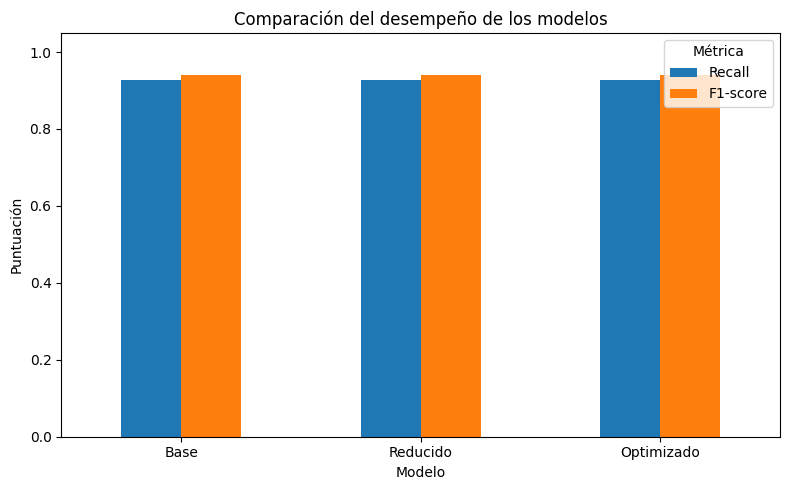

In [ ]:
comparacion_metricas = comparacion_final.set_index("Modelo")[
    ["Recall", "F1-score"]
]

comparacion_metricas.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Comparación del desempeño de los modelos")
plt.ylabel("Puntuación")
plt.xlabel("Modelo")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

Esta gráfica permite observar si la reducción de características o la optimización de hiperparámetros produjo una mejora en el desempeño.

## 7.7 Matriz de confusión del modelo optimizado

También se utilizará una matriz de confusión para analizar con mayor detalle las predicciones del modelo optimizado.

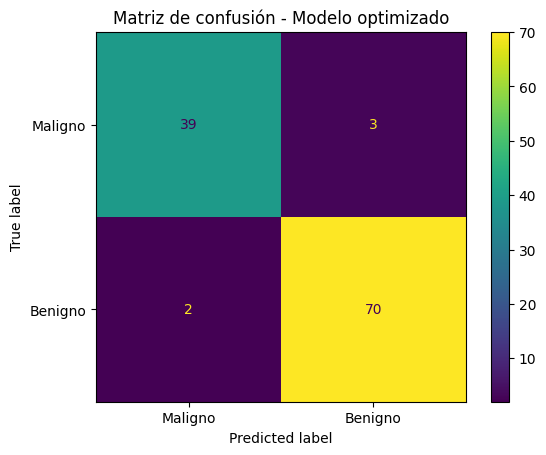

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_optimizado,
    display_labels = [
        "Maligno",
        "Benigno"
    ]
)

plt.title("Matriz de confusión - Modelo optimizado")
plt.show()

La matriz de confusión permite observar cuántos tumores malignos y benignos fueron clasificados correctamente y cuántos fueron clasificados de forma incorrecta.

# 8. Análisis final de los resultados

Después de comparar el modelo base, el modelo reducido y el modelo optimizado, es necesario analizar si la mejora obtenida realmente justifica el aumento de complejidad.

El modelo base utiliza todas las características disponibles y funciona como punto de referencia. El modelo reducido utiliza únicamente las variables seleccionadas mediante `SelectFromModel`, lo cual disminuye la cantidad de información utilizada para representar cada observación.

Si el modelo reducido conserva valores de recall y F1-score similares a los del modelo base, la selección de características puede considerarse útil, ya que permite simplificar el modelo sin perder una cantidad importante de capacidad predictiva.

Por otro lado, el modelo optimizado utiliza una configuración seleccionada mediante validación cruzada. Esto aumenta el costo computacional durante la etapa de búsqueda, debido a que se deben entrenar múltiples modelos con diferentes combinaciones de hiperparámetros.

La mejora obtenida deberá analizarse en relación con este costo adicional. Si el recall aumenta de forma considerable, el proceso de optimización puede justificarse. En cambio, si la diferencia es mínima, podría ser preferible utilizar el modelo reducido o incluso el modelo base debido a su mayor simplicidad.

## Interpretabilidad

Random Forest permite obtener la importancia relativa de las características, por lo que es posible identificar qué variables tienen mayor influencia en las predicciones.

La utilización de `SelectFromModel` conserva esta interpretabilidad porque las variables seleccionadas mantienen su significado original.

Esto representa una ventaja frente a técnicas como PCA, donde las variables originales se combinan para generar componentes nuevos cuya interpretación es menos directa.

## Sensibilidad al escalamiento

Random Forest no es especialmente sensible a la escala de las variables, debido a que los árboles realizan divisiones basadas en umbrales individuales de cada característica.

Por esta razón, no fue necesario aplicar estandarización o normalización de los datos para entrenar los modelos utilizados en esta actividad.

## Número de variables

La selección de características permitió reducir la cantidad de variables utilizadas por el modelo.

Una representación con menos características puede disminuir la complejidad, facilitar la interpretación y reducir el costo computacional del entrenamiento.

Sin embargo, eliminar demasiadas características puede provocar pérdida de información relevante, por lo que es necesario comprobar siempre el efecto de la reducción sobre las métricas de evaluación.

## Estabilidad de los resultados

La búsqueda de hiperparámetros utilizó validación cruzada de cinco particiones.

Esto permitió evaluar cada configuración utilizando diferentes subconjuntos de los datos de entrenamiento, reduciendo la dependencia de una única división entre entrenamiento y validación.

De esta forma, la configuración seleccionada se basa en un desempeño promedio y no únicamente en un resultado aislado.

## Riesgo de sobreajuste

Random Forest puede reducir el riesgo de sobreajuste al combinar las predicciones de múltiples árboles.

Sin embargo, algunos hiperparámetros pueden aumentar la complejidad del modelo. Por ejemplo, árboles excesivamente profundos pueden ajustarse demasiado a los datos de entrenamiento.

La utilización de validación cruzada durante la optimización ayuda a identificar configuraciones que funcionan de manera consistente en diferentes particiones de los datos y disminuye el riesgo de seleccionar un modelo que solamente funciona bien sobre una muestra específica.



# 9. Conclusión

En esta actividad se analizó el efecto de la selección de características y la optimización de hiperparámetros sobre un modelo de clasificación basado en **Random Forest**.

Inicialmente se entrenó un modelo base utilizando todas las características del dataset. Este modelo permitió establecer un punto de referencia utilizando como métrica principal el **recall de la clase maligna** y como métrica complementaria el **F1-score**.

Posteriormente, se utilizó `SelectFromModel` para conservar únicamente las características consideradas más relevantes por un Random Forest. Esta modificación permitió analizar si era posible reducir la cantidad de variables utilizadas sin producir una pérdida importante de desempeño.

Finalmente, se utilizó `GridSearchCV` con validación cruzada para evaluar diferentes combinaciones de hiperparámetros y seleccionar una configuración optimizada.

La modificación que produjo el mayor efecto puede identificarse comparando los valores obtenidos en la tabla final. En particular, debe observarse el cambio en recall, ya que esta fue la métrica principal seleccionada para el problema.

Si el modelo optimizado obtuvo un recall superior al modelo base, entonces la optimización permitió mejorar la capacidad de identificar correctamente tumores malignos. Sin embargo, esta mejora debe compararse con el aumento en tiempo de cómputo requerido por la búsqueda de hiperparámetros.

Si el modelo reducido logró un desempeño muy cercano al modelo optimizado utilizando menos características y un menor costo computacional, este podría representar una alternativa más sencilla y eficiente.

Por lo tanto, la configuración recomendada deberá ser aquella que ofrezca un equilibrio adecuado entre:

- capacidad para identificar correctamente los tumores malignos;
- F1-score;
- número de características utilizadas;
- tiempo de entrenamiento;
- complejidad del modelo.

Una limitación de este procedimiento es que se trabajó con un único dataset y una sola partición final de entrenamiento y prueba. Aunque la validación cruzada mejora la estabilidad durante la optimización, los resultados podrían variar si se utilizara una muestra diferente de datos.

Como trabajo posterior, se podría evaluar el modelo utilizando validación cruzada repetida, explorar un espacio de hiperparámetros más amplio o comparar Random Forest con otros algoritmos de clasificación como Gradient Boosting, SVM o regresión logística.